# Classical ML for Binary Diabetes Risk Prediction

**Course:** MDS 5 - Predictive Analytics  
**Notebook:** diabetes_ml_benchmark.ipynb  
**Dataset:** diabetes_binary_50k_stratified.csv (50,000 stratified rows)  
**Target:** Diabetes_binary (0 = no diabetes, 1 = prediabetes or diabetes)

This notebook uses **small numbered cells**, one step at a time: ingest -> EDA -> feature prep -> model benchmark.

> Start the kernel with working directory = project root (Income_prediction/).


## 1. Data Ingestion and Quality Checks

Load the stratified binary BRFSS sample and run basic quality checks before EDA.


In [1]:
# 1. Import core libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display, Image
except ImportError:
    display = print
    Image = None


In [2]:
# 2. Resolve project root and create export folders
# 论文用图/表写入 files/pic 与 files/data，供后续描述性分析引用
cwd = Path.cwd().resolve()
ROOT = None
for p in [cwd, *cwd.parents]:
    if (p / "dataset" / "diabetes_binary_50k_stratified.csv").exists():
        ROOT = p
        break
if ROOT is None:
    raise FileNotFoundError(
        "Cannot find dataset/diabetes_binary_50k_stratified.csv. "
        "Start kernel from project root, or run dataset/make_binary_50k.py first."
    )

DATA_PATH = ROOT / "dataset" / "diabetes_binary_50k_stratified.csv"
PIC_DIR = ROOT / "files" / "pic"
DATA_DIR = ROOT / "files" / "data"
PIC_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Diabetes_binary"
RANDOM_STATE = 42

print("ROOT:", ROOT)
print("DATA_PATH exists:", DATA_PATH.exists())

ROOT: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction
DATA_PATH exists: True


In [3]:
# 3. Load CSV
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
df.head()

Raw shape: (50000, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1.0,1.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,3.0,10.0,0.0,0.0,0.0,13.0,4.0,4.0,0
1,1.0,1.0,1.0,33.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,3.0,30.0,14.0,1.0,0.0,7.0,5.0,1.0,1
2,0.0,0.0,1.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,30.0,30.0,1.0,0.0,4.0,4.0,5.0,1
3,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,3.0,15.0,0.0,1.0,0.0,10.0,6.0,4.0,0
4,0.0,1.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,5.0,7.0,0


In [4]:
# 4. Basic quality checks（缺失 / 重复 / 目标分布）
# 即使缺失为 0，也要写进 Methodology，说明做过可靠性检查
print("Missing values (total):", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Class counts:")
print(df[TARGET].value_counts().sort_index())
print("Class ratio:")
print(df[TARGET].value_counts(normalize=True).sort_index().round(4))

Missing values (total): 0
Duplicate rows: 1997
Class counts:
Diabetes_binary
0    42121
1     7879
Name: count, dtype: int64
Class ratio:
Diabetes_binary
0    0.8424
1    0.1576
Name: proportion, dtype: float64


In [5]:
# 5. Sanity ranges for BMI and unhealthy-day counts
bmi_bad = ~df["BMI"].between(10, 60)
days_bad = ~(df["MentHlth"].between(0, 30) & df["PhysHlth"].between(0, 30))
print("BMI outside [10, 60]:", int(bmi_bad.sum()))
print("MentHlth/PhysHlth outside [0, 30]:", int(days_bad.sum()))

BMI outside [10, 60]: 128
MentHlth/PhysHlth outside [0, 30]: 0


In [6]:
# 6. Drop duplicates for a clean EDA / modeling baseline
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after drop_duplicates:", df.shape)
print("Class ratio after drop_duplicates:")
print(df[TARGET].value_counts(normalize=True).sort_index().round(4))

Shape after drop_duplicates: (48003, 22)
Class ratio after drop_duplicates:
Diabetes_binary
0    0.8362
1    0.1638
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

Describe class imbalance, key feature distributions, and correlations.  
Figures under `files/pic/` are primary paper Analysis material.


In [7]:
# 1. Import plotting libraries
# 启用 inline，保证 savefig 后的图也显示在 notebook 输出中
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.dpi"] = 100


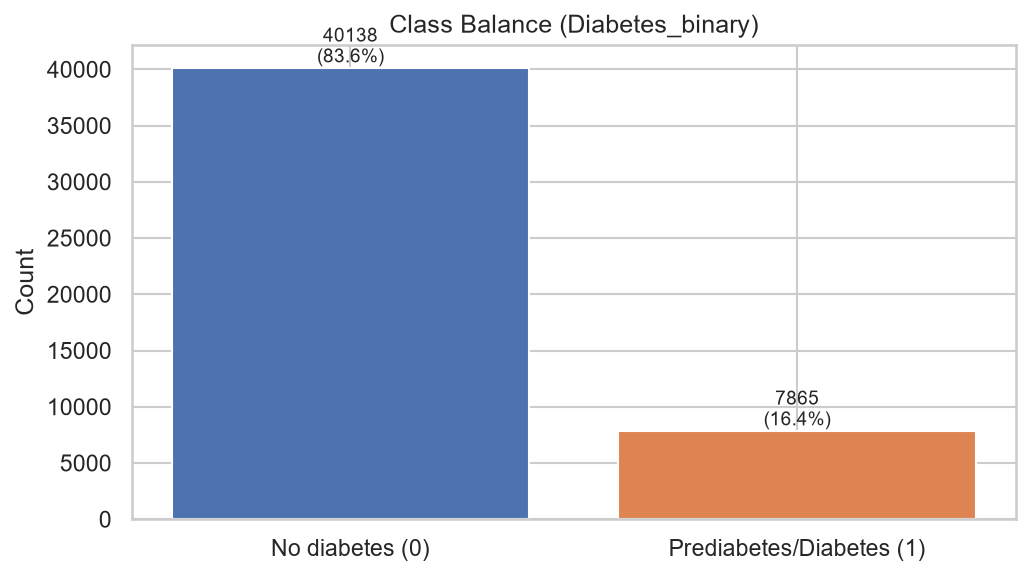

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\class_balance.png


In [8]:
# 2. Class balance bar chart -> files/pic/class_balance.png
# 描述性分析提示：约 84% vs 16%，Accuracy 会虚高，论文应主看 F1/AUC/Recall
class_counts = df[TARGET].value_counts().sort_index()
class_ratio = df[TARGET].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
labels = ["No diabetes (0)", "Prediabetes/Diabetes (1)"]
bars = ax.bar(labels, class_counts.values, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Count")
ax.set_title("Class Balance (Diabetes_binary)")
for b, v, r in zip(bars, class_counts.values, class_ratio.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{v}\n({r:.1%})",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(PIC_DIR / "class_balance.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "class_balance.png")))
print("Saved:", PIC_DIR / "class_balance.png")


In [9]:
# 3. Key descriptive statistics for numeric / ordinal features
# 用 describe 支撑 Methodology 中的数据描述
desc_cols = ["BMI", "MentHlth", "PhysHlth", "Age", "GenHlth", "Education", "Income"]
desc = df[desc_cols].describe().T.round(3)
display(desc)

,count,mean,std,min,25%,50%,75%,max
BMI,48003.0,28.471,6.524,12.0,24.0,27.0,31.0,98.0
MentHlth,48003.0,3.317,7.549,0.0,0.0,0.0,2.0,30.0
PhysHlth,48003.0,4.427,8.846,0.0,0.0,0.0,3.0,30.0
Age,48003.0,8.070,3.076,1.0,6.0,8.0,10.0,13.0
GenHlth,48003.0,2.553,1.061,1.0,2.0,2.0,3.0,5.0
Education,48003.0,5.017,0.992,1.0,4.0,5.0,6.0,6.0
Income,48003.0,5.995,2.077,1.0,5.0,7.0,8.0,8.0


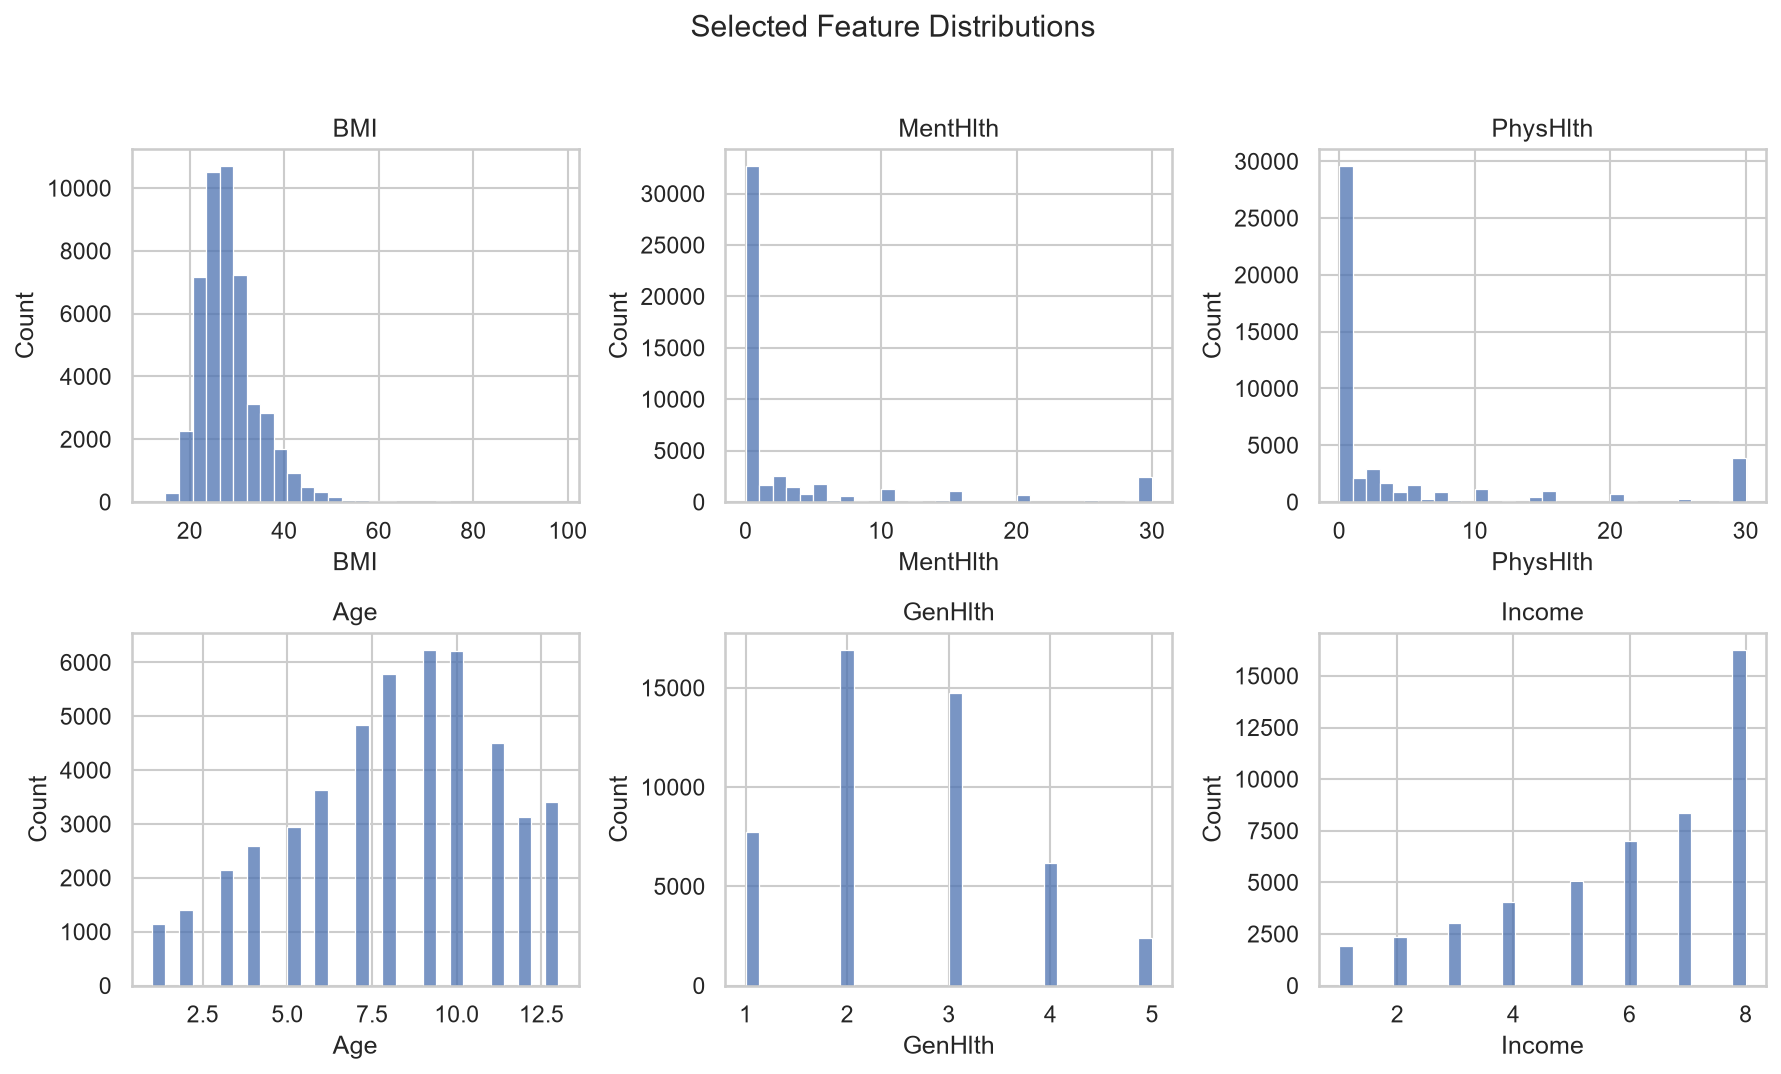

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\feature_histograms.png


In [10]:
# 4. Selected feature histograms (scale motivation)
# BMI / 天数类特征量纲不同，后续对 LR/KNN/SVM 需要标准化
cont_cols = ["BMI", "MentHlth", "PhysHlth", "Age", "GenHlth", "Income"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), cont_cols):
    sns.histplot(df[col], bins=30, ax=ax, color="#4C72B0")
    ax.set_title(col)
fig.suptitle("Selected Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(PIC_DIR / "feature_histograms.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "feature_histograms.png")))
print("Saved:", PIC_DIR / "feature_histograms.png")


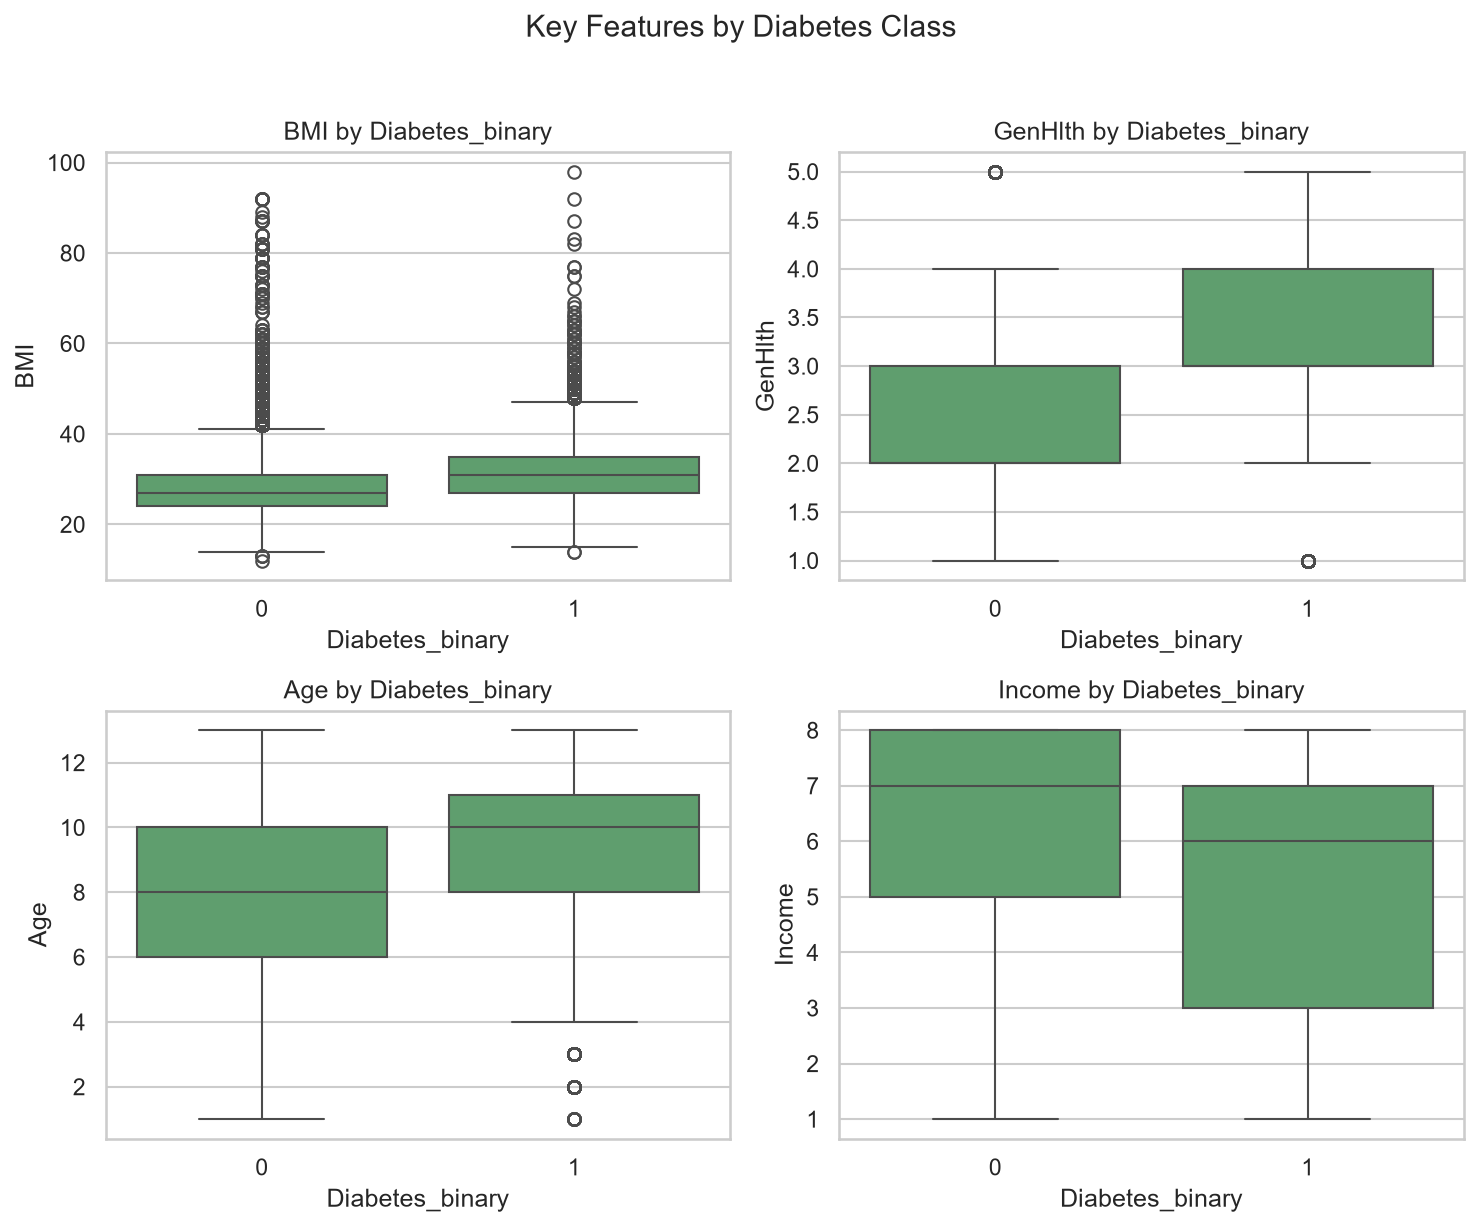

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\feature_boxplots_by_class.png


In [11]:
# 5. Boxplots of key features by diabetes class
# 观察阳性类在 BMI、GenHlth 等变量上是否整体偏高
box_cols = ["BMI", "GenHlth", "Age", "Income"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), box_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, color="#55A868")
    ax.set_title(f"{col} by {TARGET}")
    ax.set_xlabel(TARGET)
fig.suptitle("Key Features by Diabetes Class", y=1.02)
fig.tight_layout()
fig.savefig(PIC_DIR / "feature_boxplots_by_class.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "feature_boxplots_by_class.png")))
print("Saved:", PIC_DIR / "feature_boxplots_by_class.png")


## 2.1 Pearson Correlation

Compute the correlation matrix, inspect absolute correlation with the target, then plot a heatmap.  
Train-only Top-K feature selection follows in Section 3.


In [12]:
# 1. Compute Pearson correlation matrix (full cleaned frame)
corr_matrix = df.corr(method="pearson")
print("Correlation matrix shape:", corr_matrix.shape)

Correlation matrix shape: (22, 22)


In [13]:
# 2. Preview absolute correlations with the target
target_corr = corr_matrix[TARGET].drop(TARGET)
target_corr_abs = target_corr.abs().sort_values(ascending=False)
print("Top-|corr| features vs Diabetes_binary:")
print(target_corr_abs.head(12).round(4))

Top-|corr| features vs Diabetes_binary:
GenHlth                 0.2908
HighBP                  0.2649
BMI                     0.2189
DiffWalk                0.2068
HighChol                0.2046
Age                     0.1849
HeartDiseaseorAttack    0.1744
Income                  0.1650
PhysHlth                0.1620
Education               0.1249
Stroke                  0.1023
PhysActivity            0.1022
Name: Diabetes_binary, dtype: float64


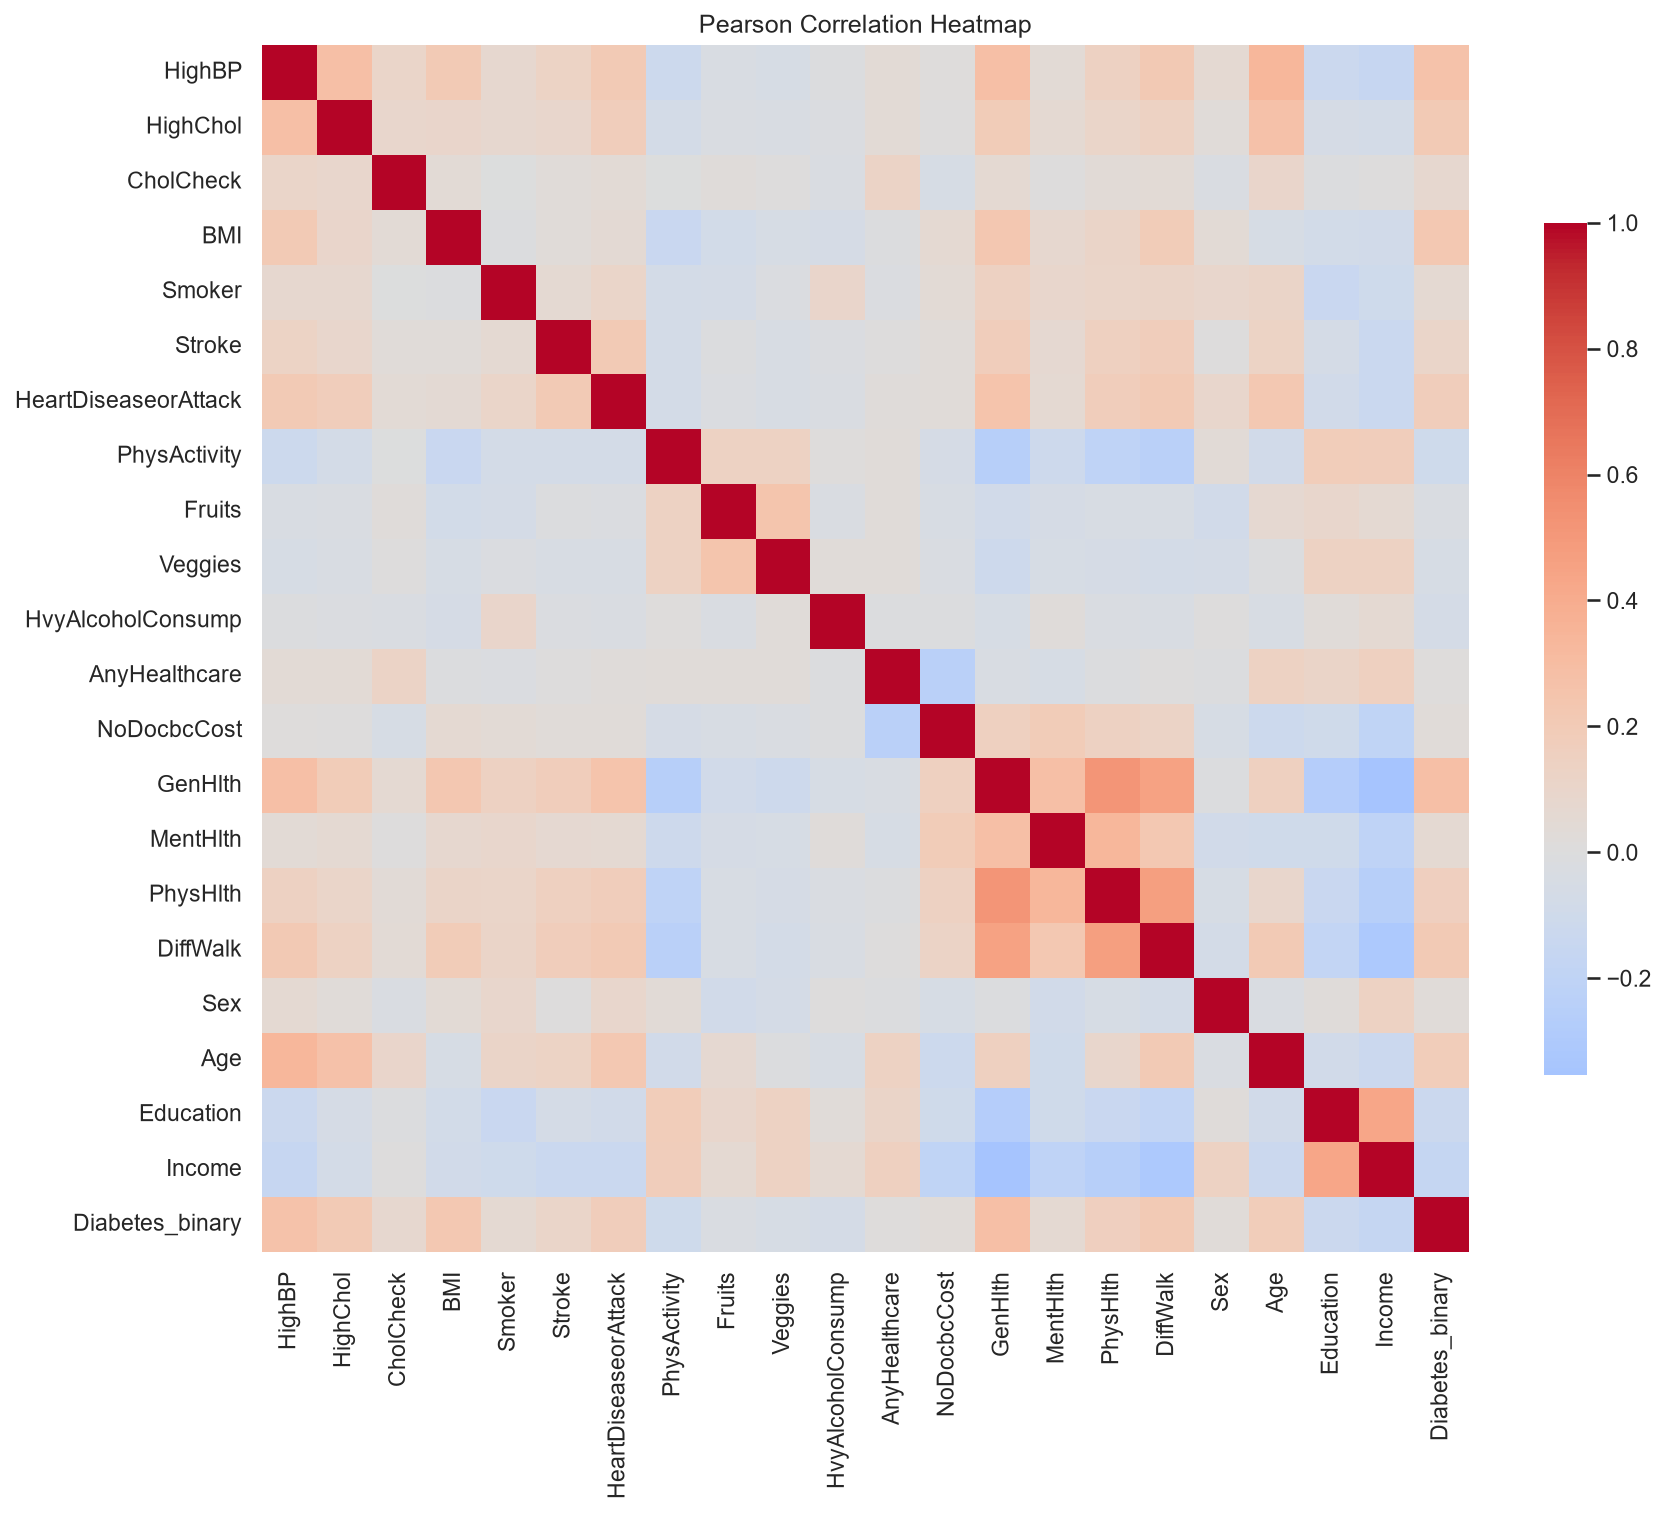

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\correlation_heatmap.png


In [14]:
# 3. Plot heatmap -> files/pic/correlation_heatmap.png
# 描述性分析提示：关注与目标强相关的临床/自评健康变量，以及特征间共线
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Pearson Correlation Heatmap")
fig.tight_layout()
fig.savefig(PIC_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "correlation_heatmap.png")))
print("Saved:", PIC_DIR / "correlation_heatmap.png")


## 2.2 EDA Findings

Paper-ready bullet points from this run (after drop_duplicates, n=48,003):

1. **Strong class imbalance:** class 0 ~ 83.6% (40,138) vs class 1 ~ 16.4% (7,865). Accuracy alone is misleading for model ranking.
2. **Top |Pearson| with target:** GenHlth (0.291), HighBP (0.265), BMI (0.219), DiffWalk (0.207), HighChol (0.205), then Age / HeartDiseaseorAttack / Income.
3. **Scale differences:** BMI, MentHlth, and PhysHlth use different units/ranges -- motivate StandardScaler for LR / KNN / SVM later.
4. **Boxplots by class:** positive class tends toward higher BMI and worse (higher) GenHlth scores.
5. **Already numeric features:** no Label Encoding step; focus on scaling and imbalance-aware metrics (F1 / AUC / Recall).

Exported EDA figures:
- iles/pic/class_balance.png
- iles/pic/feature_histograms.png
- iles/pic/feature_boxplots_by_class.png
- iles/pic/correlation_heatmap.png


In [15]:
# EDA export checklist
eda_figs = [
    PIC_DIR / "class_balance.png",
    PIC_DIR / "feature_histograms.png",
    PIC_DIR / "feature_boxplots_by_class.png",
    PIC_DIR / "correlation_heatmap.png",
]
for p in eda_figs:
    print(("OK" if p.exists() else "MISSING"), p)


OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\class_balance.png
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\feature_histograms.png
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\feature_boxplots_by_class.png
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\correlation_heatmap.png


## 3. Train/Test Split and Pearson Top-K

**Split first**, then select Top-K by |Pearson| **on the training set only** (no leakage).  
QC / de-duplication already done in earlier cells.


In [16]:
# 1. Stratified train/test split (80/20) BEFORE feature selection
# 先划分再选特征，避免用全数据相关造成泄漏
from sklearn.model_selection import train_test_split

TOP_K = 8  # 本项目特征约 21 个，取 Top-8 平衡信息量与简洁性

feature_cols_all = [c for c in df.columns if c != TARGET]
X_all = df[feature_cols_all]
y = df[TARGET]

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train_all.shape, "Test:", X_test_all.shape)
print("Train class ratio:")
print(y_train.value_counts(normalize=True).sort_index().round(4))
print("random_state:", RANDOM_STATE, "| TOP_K:", TOP_K)


Train: (38402, 21) Test: (9601, 21)
Train class ratio:
Diabetes_binary
0    0.8362
1    0.1638
Name: proportion, dtype: float64
random_state: 42 | TOP_K: 8


In [17]:
# 2. Rank features by |Pearson| with target on the TRAINING set only
train_tmp = X_train_all.copy()
train_tmp[TARGET] = y_train.values
corr_train = train_tmp.corr(method="pearson")[TARGET].drop(TARGET)
abs_corr = corr_train.abs().sort_values(ascending=False)

top_features = abs_corr.head(TOP_K).index.tolist()
print(f"Top {TOP_K} selected features (train-only Pearson):")
print(top_features)
print(abs_corr.head(TOP_K).round(4))

Top 8 selected features (train-only Pearson):
['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol', 'Age', 'HeartDiseaseorAttack', 'Income']
GenHlth                 0.2900
HighBP                  0.2648
BMI                     0.2208
DiffWalk                0.2090
HighChol                0.2059
Age                     0.1832
HeartDiseaseorAttack    0.1702
Income                  0.1634
Name: Diabetes_binary, dtype: float64


In [18]:
# 3. Build selected-feature table and export -> files/data/selected_features.csv
selected_table = pd.DataFrame(
    {
        "feature": top_features,
        "pearson_corr": corr_train.loc[top_features].values,
        "abs_pearson_corr": abs_corr.loc[top_features].values,
    }
)
display(selected_table.round(4))
selected_path = DATA_DIR / "selected_features.csv"
selected_table.to_csv(selected_path, index=False)
print("Saved:", selected_path)

,feature,pearson_corr,abs_pearson_corr
0,GenHlth,0.2900,0.2900
1,HighBP,0.2648,0.2648
2,BMI,0.2208,0.2208
3,DiffWalk,0.2090,0.2090
4,HighChol,0.2059,0.2059
5,Age,0.1832,0.1832
6,HeartDiseaseorAttack,0.1702,0.1702
7,Income,-0.1634,0.1634


Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\selected_features.csv


In [19]:
# 4. Filter X to Top-K features only
# 只保留训练集上选出的 Top-K 特征列，供后续缩放与建模使用
X_train = X_train_all[top_features]
X_test = X_test_all[top_features]
print("X_train:", X_train.shape, "X_test:", X_test.shape)
X_train.head()


X_train: (38402, 8) X_test: (9601, 8)


,GenHlth,HighBP,BMI,DiffWalk,HighChol,Age,HeartDiseaseorAttack,Income
19741,1.0,0.0,23.0,0.0,1.0,6.0,0.0,8.0
3970,2.0,1.0,24.0,0.0,0.0,13.0,0.0,8.0
46416,2.0,0.0,30.0,0.0,0.0,3.0,0.0,4.0
42340,2.0,0.0,23.0,0.0,0.0,4.0,0.0,5.0
14962,3.0,1.0,30.0,0.0,0.0,6.0,0.0,8.0


## 3.1 Feature Scaling

`StandardScaler` is fit **on the training set only**, then applied to train and test.  
Tree models do not require scaling, but we scale once for a fair multi-model comparison (LR / KNN / Linear SVM especially).


In [20]:
# 5. StandardScaler: fit on train, transform train/test
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train mean ~0:", np.round(X_train_scaled.mean(axis=0), 5))
print("Scaled train std ~1:", np.round(X_train_scaled.std(axis=0), 5))
print("Scaler fitted on train only; test transformed with the same scaler.")

Scaled train mean ~0: [-0. -0.  0.  0.  0.  0.  0. -0.]
Scaled train std ~1: [1. 1. 1. 1. 1. 1. 1. 1.]
Scaler fitted on train only; test transformed with the same scaler.


In [21]:
# 6. Feature-prep pipeline checklist
print("OK random_state =", RANDOM_STATE)
print("OK TOP_K =", TOP_K)
print("OK top_features =", top_features)
print("OK selected_features.csv exists:", (DATA_DIR / "selected_features.csv").exists())
print("OK X_train_scaled shape:", X_train_scaled.shape)
print("OK X_test_scaled shape:", X_test_scaled.shape)


OK random_state = 42
OK TOP_K = 8
OK top_features = ['GenHlth', 'HighBP', 'BMI', 'DiffWalk', 'HighChol', 'Age', 'HeartDiseaseorAttack', 'Income']
OK selected_features.csv exists: True
OK X_train_scaled shape: (38402, 8)
OK X_test_scaled shape: (9601, 8)


## 4. Train, Predict, and Evaluate

Train at least 4 classical models on the **scaled Top-8** features from Section 3.  
Primary ranking metrics under imbalance: **F1 / AUC / Recall** (Accuracy is secondary).


In [22]:
# 1. Import models and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import time

In [23]:
# 2. Initialize the 5 classical models（课设要求 ≥4）
# LinearSVC：50k 样本下比 RBF-SVC 可跑；AUC 用 decision_function
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
}
list(models.keys())


['Logistic Regression',
 'K-Nearest Neighbors',
 'Decision Tree',
 'Random Forest',
 'Linear SVM']

In [24]:
# 3. Helper: continuous score for AUC / ROC
def get_scores(model, X):
    # 有概率用概率；LinearSVC 用 decision_function
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)

In [25]:
# 4. Train all models and collect metrics / scores
results = []
fitted = {}
preds = {}
scores = {}

print("Training models...")
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    train_time = time.perf_counter() - t0

    y_pred = model.predict(X_test_scaled)
    y_score = get_scores(model, X_test_scaled)

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_test, y_score),
            "TrainTimeSec": train_time,
        }
    )
    fitted[name] = model
    preds[name] = y_pred
    scores[name] = y_score
    print(f"  done: {name}")

Training models...
  done: Logistic Regression


  done: K-Nearest Neighbors
  done: Decision Tree


  done: Random Forest
  done: Linear SVM


In [26]:
# 5. Performance table（按 F1 排序；不平衡场景主看 F1 / AUC / Recall）
df_results = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
print("=== Model Evaluation Performance Table ===")
display(df_results.round(4))

metrics_path = DATA_DIR / "metrics_benchmark.csv"
df_results.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)

=== Model Evaluation Performance Table ===


,Model,Accuracy,Precision,Recall,F1-Score,AUC,TrainTimeSec
1,K-Nearest Neighbors,0.8170,0.4004,0.2352,0.2964,0.7087,0.0829
2,Decision Tree,0.8352,0.4931,0.2034,0.2880,0.7706,0.0383
3,Random Forest,0.8393,0.5284,0.1774,0.2656,0.8017,0.4824
0,Logistic Regression,0.8410,0.5467,0.1710,0.2605,0.8067,0.0194
4,Linear SVM,0.8416,0.6024,0.0973,0.1675,0.8070,0.0193


Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_benchmark.csv


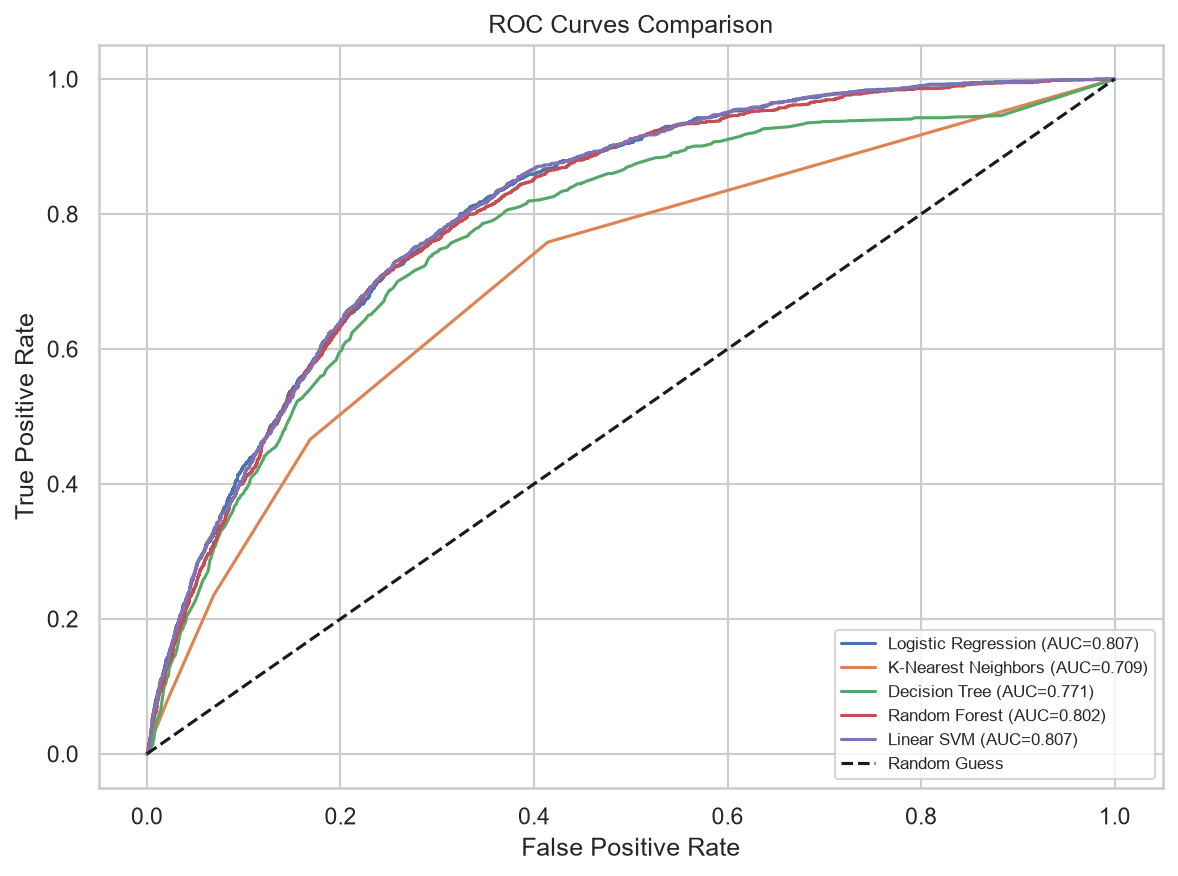

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\roc_curves_benchmark.png


In [27]:
# 6. ROC curves for all models -> files/pic/roc_curves_benchmark.png
# 描述性分析提示：比较曲线抬升与 AUC；勿只报告 Accuracy
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_score in scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_score):.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves Comparison")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)
fig.tight_layout()
fig.savefig(PIC_DIR / "roc_curves_benchmark.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "roc_curves_benchmark.png")))
print("Saved:", PIC_DIR / "roc_curves_benchmark.png")


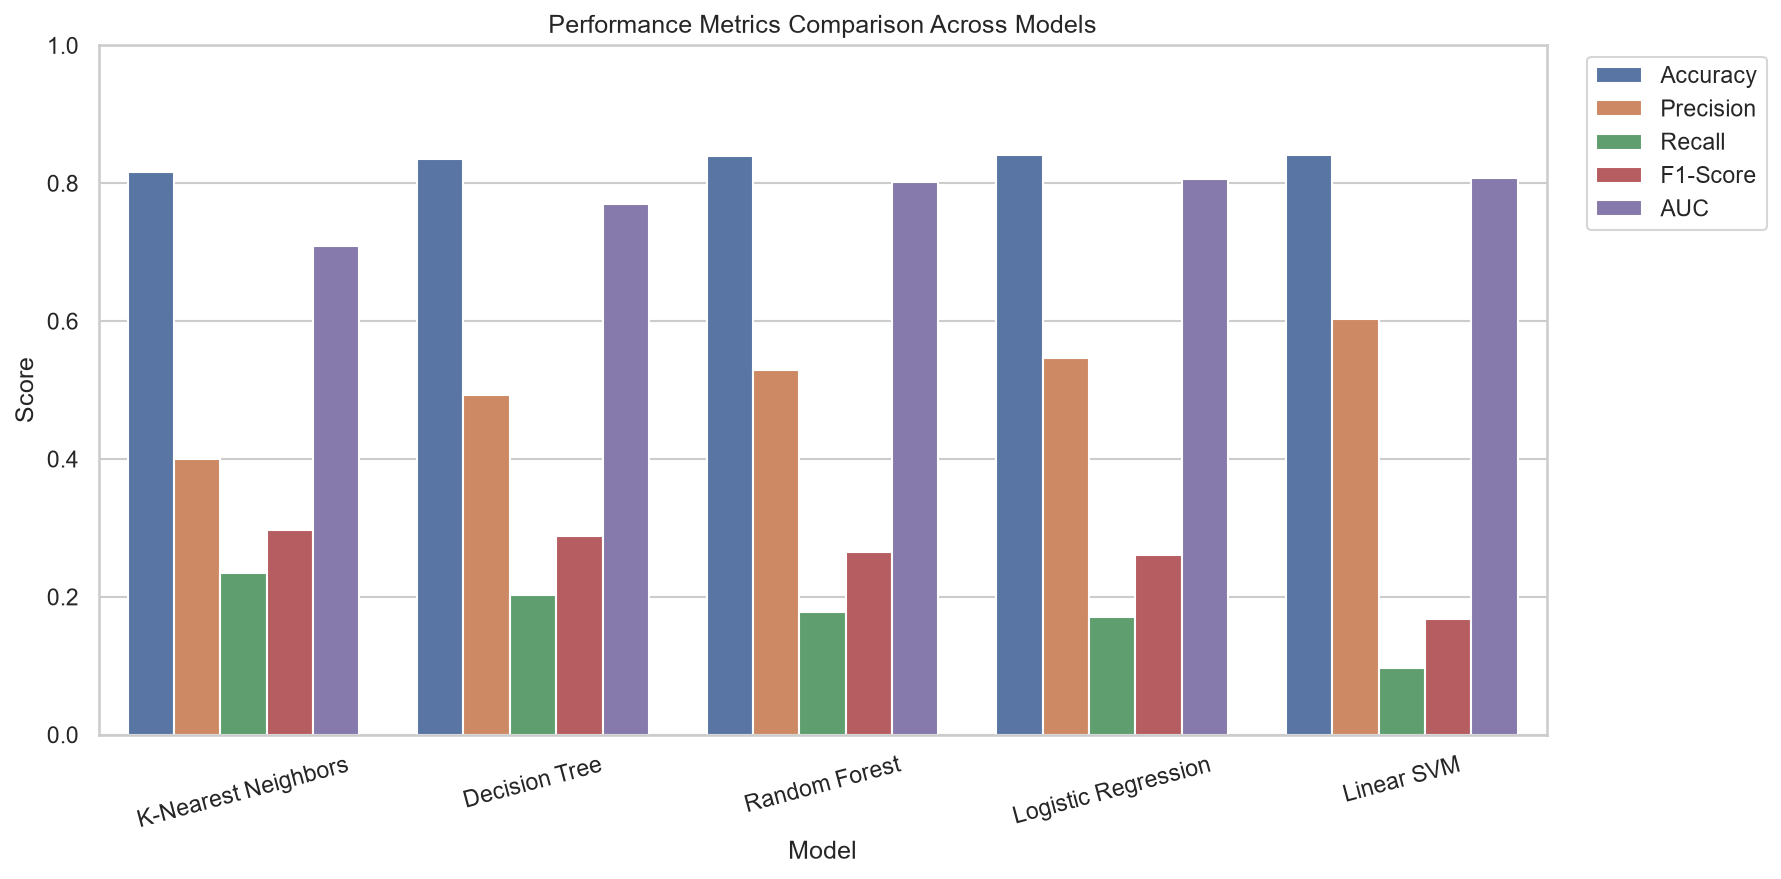

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\metrics_bar_benchmark.png


In [28]:
# 7. Bar chart of metrics（辅助读表）
df_melted = df_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    var_name="Metric",
    value_name="Score",
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Performance Metrics Comparison Across Models")
ax.tick_params(axis="x", rotation=15)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(PIC_DIR / "metrics_bar_benchmark.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "metrics_bar_benchmark.png")))
print("Saved:", PIC_DIR / "metrics_bar_benchmark.png")


Best model by F1-Score: K-Nearest Neighbors


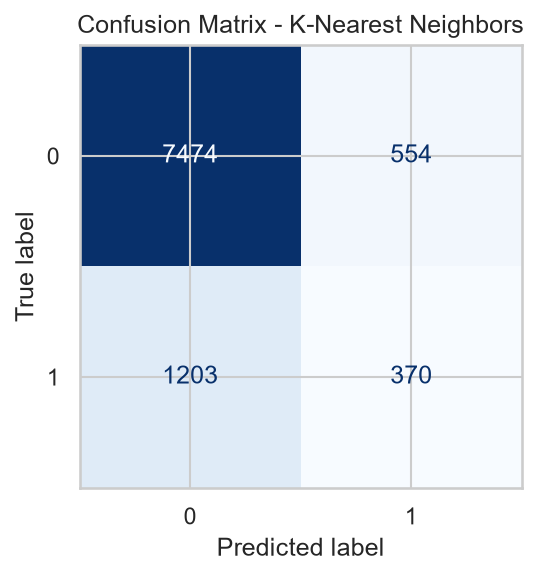

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\confusion_matrix_best.png
TN FP / FN TP:
 [[7474  554]
 [1203  370]]


In [29]:
# 8. Confusion matrix for best F1 model -> files/pic/confusion_matrix_best.png
best_name = df_results.iloc[0]["Model"]
print("Best model by F1-Score:", best_name)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, preds[best_name])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Confusion Matrix - {best_name}")
fig.tight_layout()
fig.savefig(PIC_DIR / "confusion_matrix_best.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "confusion_matrix_best.png")))
print("Saved:", PIC_DIR / "confusion_matrix_best.png")
print("TN FP / FN TP:\n", cm)


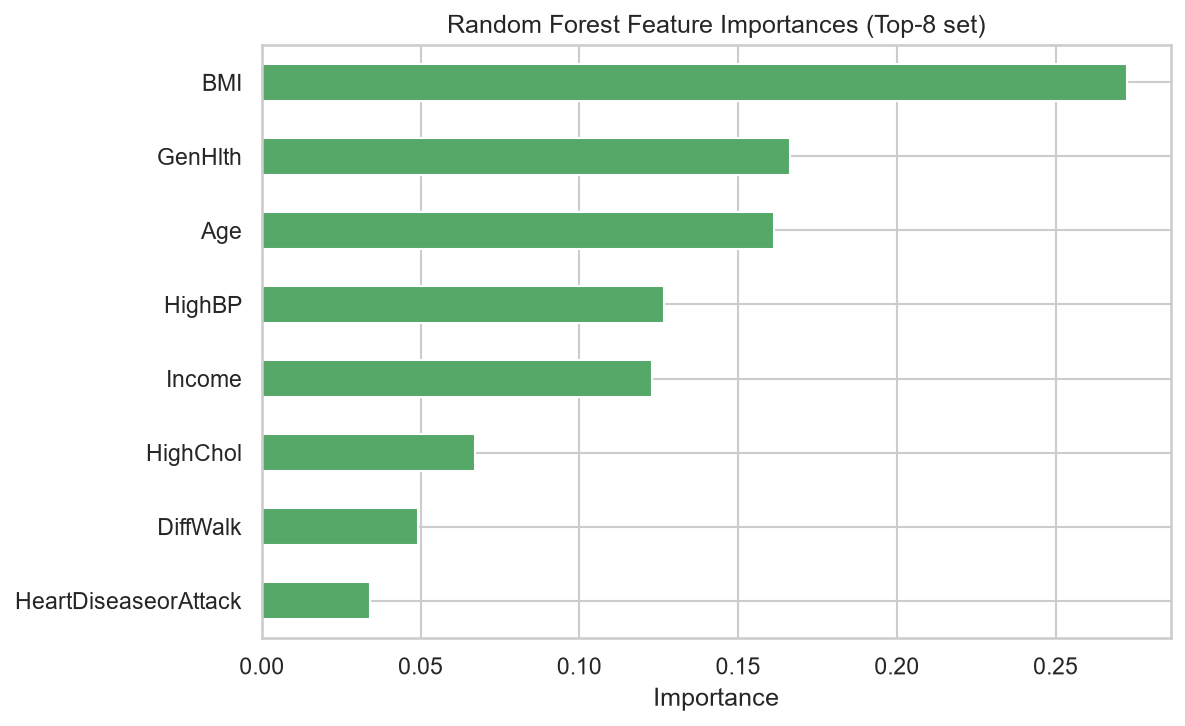

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\rf_feature_importance.png


,importance
BMI,0.2726
GenHlth,0.1662
Age,0.1612
HighBP,0.1266
Income,0.1230
HighChol,0.0671
DiffWalk,0.0492
HeartDiseaseorAttack,0.0342


In [30]:
# 9. Random Forest feature importances -> files/pic/rf_feature_importance.png
# 描述性分析提示：与 Pearson Top-8 对照，讨论线性相关 vs 树模型非线性贡献
rf_model = fitted["Random Forest"]
imp = pd.Series(rf_model.feature_importances_, index=top_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importances (Top-8 set)")
fig.tight_layout()
fig.savefig(PIC_DIR / "rf_feature_importance.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "rf_feature_importance.png")))
print("Saved:", PIC_DIR / "rf_feature_importance.png")
display(imp.sort_values(ascending=False).round(4).to_frame("importance"))


## 4.1 Class Imbalance Comparison

Default vs `class_weight='balanced'` for Logistic Regression and Random Forest.  
Describe how **Recall / F1** change relative to **Accuracy** (Accuracy trap).


In [31]:
# 10. Define imbalance ablation models
imbalance_models = {
    "LR (none)": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "LR (balanced)": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "RF (none)": RandomForestClassifier(
        n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "RF (balanced)": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}
list(imbalance_models.keys())

['LR (none)', 'LR (balanced)', 'RF (none)', 'RF (balanced)']

In [32]:
# 11. Train ablation models and collect metrics
imbalance_results = []
for name, model in imbalance_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_score = get_scores(model, X_test_scaled)
    imbalance_results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_test, y_score),
        }
    )
    print(name, "done")

df_imbalance = pd.DataFrame(imbalance_results)
display(df_imbalance.round(4))

ablation_path = DATA_DIR / "metrics_imbalance_ablation.csv"
df_imbalance.to_csv(ablation_path, index=False)
print("Saved:", ablation_path)

LR (none) done
LR (balanced) done


RF (none) done


RF (balanced) done


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,LR (none),0.8410,0.5467,0.1710,0.2605,0.8067
1,LR (balanced),0.7233,0.3421,0.7463,0.4691,0.8074
2,RF (none),0.8393,0.5284,0.1774,0.2656,0.8017
3,RF (balanced),0.7388,0.3509,0.6993,0.4673,0.7976


Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_imbalance_ablation.csv


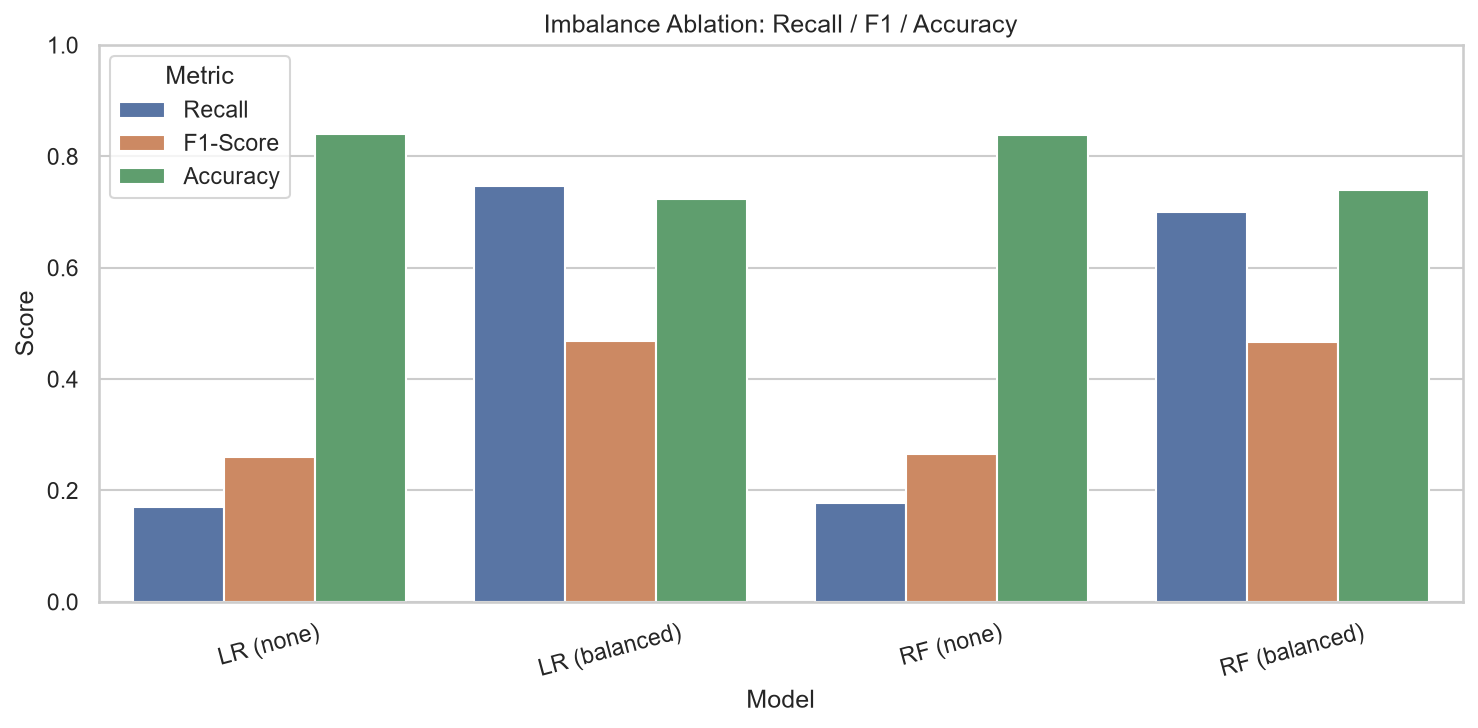

Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\imbalance_f1_recall_comparison.png


In [33]:
# 12. Ablation bar chart -> files/pic/imbalance_f1_recall_comparison.png
# 描述性分析提示：balanced 常提高阳性 Recall，Accuracy 可能下降——写进 Analysis 权衡
plot_df = df_imbalance.melt(
    id_vars=["Model"],
    value_vars=["Recall", "F1-Score", "Accuracy"],
    var_name="Metric",
    value_name="Score",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Imbalance Ablation: Recall / F1 / Accuracy")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(PIC_DIR / "imbalance_f1_recall_comparison.png", bbox_inches="tight")
plt.close(fig)
# 同时在 notebook 中显示已保存图片（不只写磁盘）
if Image is not None:
    display(Image(filename=str(PIC_DIR / "imbalance_f1_recall_comparison.png")))
print("Saved:", PIC_DIR / "imbalance_f1_recall_comparison.png")


## 4.2 Findings and Recommendation

Keep this short. Paper Analysis should describe the **figures and tables** just produced.


In [34]:
# 13. Short English draft for Conclusions + export Markdown tables
best = df_results.iloc[0]
print("Best by F1 (default weights):", best["Model"])
print(
    f"Hold-out: F1={best['F1-Score']:.4f}, AUC={best['AUC']:.4f}, "
    f"Accuracy={best['Accuracy']:.4f}, Recall={best['Recall']:.4f}."
)
print(
    "Under ~16% positives, recommend ranking models by F1/AUC/Recall, not Accuracy alone."
)
print("Highest Recall in imbalance ablation:")
display(df_imbalance.sort_values("Recall", ascending=False).head(1).round(4))
print(
    "Screening-oriented draft recommendation: prefer class_weight='balanced' "
    "(especially Logistic Regression) when minority detection matters."
)

# Markdown tables for README / paper paste（不依赖 tabulate）
def df_to_md(frame: pd.DataFrame) -> str:
    cols = list(frame.columns)
    lines = [
        "| " + " | ".join(cols) + " |",
        "| " + " | ".join(["---"] * len(cols)) + " |",
    ]
    for _, row in frame.iterrows():
        lines.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(lines)


md_bench = DATA_DIR / "metrics_benchmark.md"
md_abl = DATA_DIR / "metrics_imbalance_ablation.md"
md_bench.write_text(
    "# Model Benchmark Results\n\n" + df_to_md(df_results.round(4)) + "\n",
    encoding="utf-8",
)
md_abl.write_text(
    "# Imbalance Ablation\n\n" + df_to_md(df_imbalance.round(4)) + "\n",
    encoding="utf-8",
)
print("Saved:", md_bench)
print("Saved:", md_abl)

Best by F1 (default weights): K-Nearest Neighbors
Hold-out: F1=0.2964, AUC=0.7087, Accuracy=0.8170, Recall=0.2352.
Under ~16% positives, recommend ranking models by F1/AUC/Recall, not Accuracy alone.
Highest Recall in imbalance ablation:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
1,LR (balanced),0.7233,0.3421,0.7463,0.4691,0.8074


Screening-oriented draft recommendation: prefer class_weight='balanced' (especially Logistic Regression) when minority detection matters.
Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_benchmark.md
Saved: D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_imbalance_ablation.md


In [35]:
# 14. Modeling export checklist
checks = [
    DATA_DIR / "metrics_benchmark.csv",
    DATA_DIR / "metrics_imbalance_ablation.csv",
    DATA_DIR / "metrics_benchmark.md",
    DATA_DIR / "metrics_imbalance_ablation.md",
    PIC_DIR / "roc_curves_benchmark.png",
    PIC_DIR / "confusion_matrix_best.png",
    PIC_DIR / "rf_feature_importance.png",
    PIC_DIR / "imbalance_f1_recall_comparison.png",
]
for p in checks:
    print(("OK" if p.exists() else "MISSING"), p)


OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_benchmark.csv
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_imbalance_ablation.csv
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_benchmark.md
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\data\metrics_imbalance_ablation.md
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\roc_curves_benchmark.png
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\confusion_matrix_best.png
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\rf_feature_importance.png
OK D:\code\xu-term2\Master_data_science\MDS 5 Predictive Analytics\Income_prediction\files\pic\imbalance_f1_recall_comparison.png
